In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
df = pd.read_csv('bank_transactions.cs')

In [5]:
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [6]:
df.isnull().sum()


TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation                151
CustAccountBalance         2369
TransactionDate               0
TransactionTime               0
TransactionAmount (INR)       0
dtype: int64

In [7]:
df.dropna(subset=['CustomerID', 'TransactionAmount (INR)'], inplace=True)

In [9]:
df['CustomerDOB'].head(10)

0   1994-10-01
1   2057-04-04
2   1996-11-26
3   2073-09-14
4   1988-03-24
5   2072-08-10
6   1992-01-26
7   1982-01-27
8   1988-04-19
9   1984-06-22
Name: CustomerDOB, dtype: datetime64[ns]

In [10]:
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], format='%d-%m-%Y', errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], format='%d-%m-%Y', errors='coerce')

In [12]:
df['TransactionTime'] = pd.to_datetime(df['TransactionTime'], unit='s', errors='coerce').dt.time

In [13]:
df = df[df['TransactionDate'] <= pd.Timestamp.today()]

In [14]:
df['CustomerAge'] = (pd.Timestamp.today() - df['CustomerDOB']).dt.days // 365

In [15]:
df.rename(columns={
    'TransactionAmount (INR)': 'TransactionAmount',
    'CustGender': 'Gender',
    'CustLocation': 'Location',
    'CustAccountBalance': 'AccountBalance'
}, inplace=True)

In [17]:
df.to_csv('cleaned_bank_transactions.csv', index=False)

In [18]:
import matplotlib.pyplot as plt

In [19]:
import seaborn as sns

In [20]:
df = pd.read_csv('cleaned_bank_transactions.csv')

In [21]:
df.head()

,TransactionID,CustomerID,CustomerDOB,Gender,Location,AccountBalance,TransactionDate,TransactionTime,TransactionAmount,CustomerAge
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,NaN,25.0,30.0
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-02-08,NaN,27999.0,-32.0
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-02-08,NaN,459.0,28.0
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-02-08,NaN,2060.0,-49.0
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-02-08,NaN,1762.5,37.0


In [22]:
df['TransactionTime'] = pd.to_datetime(df['TransactionTime'], unit='s', errors='coerce')

In [26]:
# 1. Convert 'CustomerDOB' to datetime format (in case it's still a string)
df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')

In [27]:
df = df[df['CustomerDOB'].notna()]  
df = df[df['CustomerDOB'] <= pd.Timestamp.today()]

In [28]:
df['CustomerAge'] = (pd.Timestamp.today() - df['CustomerDOB']).dt.days // 365

In [29]:
df.head()

,TransactionID,CustomerID,CustomerDOB,Gender,Location,AccountBalance,TransactionDate,TransactionTime,TransactionAmount,CustomerAge
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,NaT,25.0,30
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-02-08,NaT,459.0,28
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-02-08,NaT,1762.5,37
6,T7,C7126560,1992-01-26,F,MUMBAI,973.46,2016-02-08,NaT,566.0,33
7,T8,C1220223,1982-01-27,M,MUMBAI,95075.54,2016-02-08,NaT,148.0,43


In [30]:
df['TransactionTime'] = pd.to_datetime(df['TransactionTime'], unit='s', errors='coerce')


In [32]:
df.to_csv('cleaned_and_validated_bank_transactions.csv', index=False)

In [33]:
df.head()

,TransactionID,CustomerID,CustomerDOB,Gender,Location,AccountBalance,TransactionDate,TransactionTime,TransactionAmount,CustomerAge
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,NaT,25.0,30
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-02-08,NaT,459.0,28
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-02-08,NaT,1762.5,37
6,T7,C7126560,1992-01-26,F,MUMBAI,973.46,2016-02-08,NaT,566.0,33
7,T8,C1220223,1982-01-27,M,MUMBAI,95075.54,2016-02-08,NaT,148.0,43


In [34]:
# Check unique values in TransactionTime to understand its format
print(df['TransactionTime'].unique())

<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[ns]


In [35]:
# Check the first few values in TransactionTime to see what's inside
df['TransactionTime'].head(20)

0    NaT
2    NaT
4    NaT
6    NaT
7    NaT
8    NaT
9    NaT
10   NaT
11   NaT
12   NaT
13   NaT
14   NaT
16   NaT
17   NaT
18   NaT
19   NaT
20   NaT
21   NaT
22   NaT
23   NaT
Name: TransactionTime, dtype: datetime64[ns]

In [36]:
# Check for missing values in the 'TransactionTime' column
missing_count = df['TransactionTime'].isna().sum()
print(f"Number of missing values in TransactionTime: {missing_count}"

Number of missing values in TransactionTime: 939967


In [40]:
print(df.columns)

Index(['TransactionID', 'CustomerID', 'CustomerDOB', 'Gender', 'Location',
       'AccountBalance', 'TransactionDate', 'TransactionAmount',
       'CustomerAge'],
      dtype='object')


In [41]:
print(df.dtypes)

TransactionID                object
CustomerID                   object
CustomerDOB          datetime64[ns]
Gender                       object
Location                     object
AccountBalance              float64
TransactionDate              object
TransactionAmount           float64
CustomerAge                   int64
dtype: object


In [42]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

In [43]:
print(df.dtypes)

TransactionID                object
CustomerID                   object
CustomerDOB          datetime64[ns]
Gender                       object
Location                     object
AccountBalance              float64
TransactionDate      datetime64[ns]
TransactionAmount           float64
CustomerAge                   int64
dtype: object


In [44]:
print(df.isna().sum())

TransactionID           0
CustomerID              0
CustomerDOB             0
Gender                886
Location              111
AccountBalance       2147
TransactionDate         0
TransactionAmount       0
CustomerAge             0
dtype: int64


In [46]:
df['Gender'] = df['Gender'].fillna('Unknown')
df['Location'] = df['Location'].fillna('Unknown')

In [47]:
df['AccountBalance'] = df['AccountBalance'].fillna(df['AccountBalance'].median())

In [48]:
print(df.isna().sum())

TransactionID        0
CustomerID           0
CustomerDOB          0
Gender               0
Location             0
AccountBalance       0
TransactionDate      0
TransactionAmount    0
CustomerAge          0
dtype: int64


In [50]:
df.to_csv('cleaned_bank_transactions_with_no_missing_values.csv', index=False)

In [1]:
import sqlite3
import pandas as pd

In [2]:
df = pd.read_csv("cleaned_bank_transactions_with_no_missing_values.csv")

In [3]:
conn = sqlite3.connect("bank_data.db")

In [4]:
df.to_sql("transactions", conn, if_exists="replace", index=False)

939967

In [5]:
query_result = pd.read_sql("SELECT * FROM transactions LIMIT 5;", conn)
print(query_result)

  TransactionID CustomerID CustomerDOB Gender     Location  AccountBalance  \
0            T1   C5841053  1994-10-01      F   JAMSHEDPUR        17819.05   
1            T3   C4417068  1996-11-26      F       MUMBAI        17874.44   
2            T5   C9031234  1988-03-24      F  NAVI MUMBAI         6714.43   
3            T7   C7126560  1992-01-26      F       MUMBAI          973.46   
4            T8   C1220223  1982-01-27      M       MUMBAI        95075.54   

  TransactionDate  TransactionAmount  CustomerAge  
0      2016-02-08               25.0           30  
1      2016-02-08              459.0           28  
2      2016-02-08             1762.5           37  
3      2016-02-08              566.0           33  
4      2016-02-08              148.0           43  


In [6]:
pd.read_sql("SELECT COUNT(*) FROM transactions;", conn)

,COUNT(*)
0,939967


In [7]:
pd.read_sql("""
SELECT Gender, SUM(TransactionAmount) as TotalAmount
FROM transactions
GROUP BY Gender;
""", conn)

,Gender,TotalAmount
0,F,3.767497e+08
1,M,9.470677e+08
2,T,3.250000e+04
3,Unknown,1.609186e+06


In [8]:
pd.read_sql("""
SELECT Location, AVG(AccountBalance) as AvgBalance
FROM transactions
GROUP BY Location
ORDER BY AvgBalance DESC;
""", conn)

,Location,AvgBalance
0,PO BOX 28483 DUBAI,21696661.00
1,RENTON,20773103.40
2,MERCEDES SHOWROOM MUMBAI,7567497.40
3,BORIVALI WEST,6011185.61
4,SAKAKA,5441524.53
...,...,...
8642,DOMBIVLI EAST DOMBIVLI,0.00
8643,DEVALI,0.00
8644,DENAP,0.00
8645,CORPORATION THANE,0.00


In [5]:
# Import necessary libraries
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("cleaned_bank_transactions_with_no_missing_values.csv")

# Basic Info about the DataFrame
print(df.info())

# Basic Descriptive Statistics
print(df.describe())

# Total number of transactions
total_transactions = len(df)
print(f"Total Transactions: {total_transactions}")

# Total transaction amount by location
transaction_by_location = df.groupby("Location")["TransactionAmount"].sum().sort_values(ascending=False)
print(transaction_by_location.head(10))  # Top 10 locations by transaction amount

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 939967 entries, 0 to 939966
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   TransactionID      939967 non-null  object 
 1   CustomerID         939967 non-null  object 
 2   CustomerDOB        939967 non-null  object 
 3   Gender             939967 non-null  object 
 4   Location           939967 non-null  object 
 5   AccountBalance     939967 non-null  float64
 6   TransactionDate    939967 non-null  object 
 7   TransactionAmount  939967 non-null  float64
 8   CustomerAge        939967 non-null  int64  
dtypes: float64(2), int64(1), object(6)
memory usage: 64.5+ MB
None
       AccountBalance  TransactionAmount    CustomerAge
count    9.399670e+05       9.399670e+05  939967.000000
mean     8.851117e+04       1.410112e+03      48.483262
std      4.586564e+05       5.983407e+03      45.271111
min      0.000000e+00       0.000000e+00       1.000000
25%

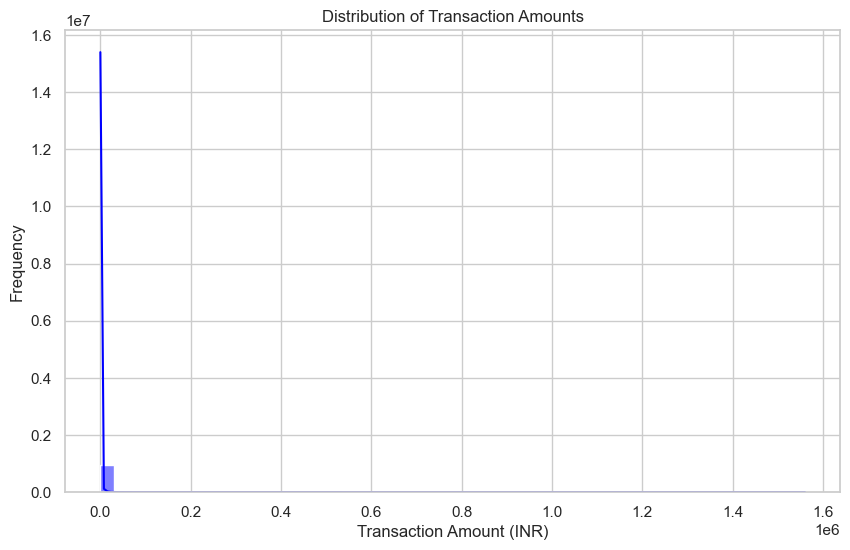

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the style
sns.set(style="whitegrid")

# Plot distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['TransactionAmount'], bins=50, kde=True, color="blue")
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount (INR)")
plt.ylabel("Frequency")
plt.show()

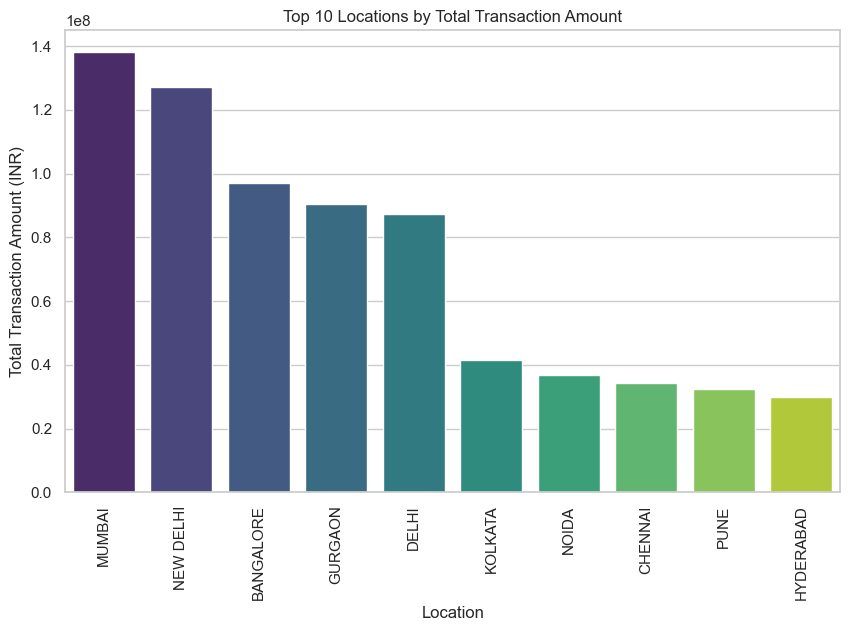

In [8]:
# Plot total transaction amount by location with hue (using 'hue' with 'Location')
plt.figure(figsize=(10, 6))
sns.barplot(x=location_data.index, y=location_data.values, hue=location_data.index, palette="viridis", legend=False)
plt.title("Top 10 Locations by Total Transaction Amount")
plt.xlabel("Location")
plt.ylabel("Total Transaction Amount (INR)")
plt.xticks(rotation=90)  # Rotate the labels to avoid overlap
plt.show()

In [9]:
# Make sure 'TransactionDate' is in datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

# Extract the year from the transaction date
df['Year'] = df['TransactionDate'].dt.year

# Total transaction amount per year
yearly_transactions = df.groupby('Year')['TransactionAmount'].sum()

# Calculate Year-over-Year growth
yoy_growth = yearly_transactions.pct_change() * 100
print("Year-over-Year Growth (%)")
print(yoy_growth)

Year-over-Year Growth (%)
Year
2016   NaN
Name: TransactionAmount, dtype: float64


In [10]:
# Save YoY growth to CSV
yoy_growth.to_csv("yoy_growth.csv", header=True)

# Save the top-performing locations to CSV
top_locations = location_data.head(10)
top_locations.to_csv("top_locations.csv", header=True)